In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv('50_Startups_dataset.csv')

In [3]:
df.head()

,Unnamed: 0,R&D Spend,Administration,Marketing Spend,State,Profit
0,0,165349.30,136897.90,471784.20,New York,192261.93
1,1,162597.80,151377.69,443898.63,California,191792.16
2,2,153441.61,101145.65,407934.64,Florida,191050.49
3,3,144372.51,118671.95,383199.72,New York,182902.09
4,4,142107.44,91391.87,366168.52,Florida,166188.04


In [4]:
df.drop(columns=['Unnamed: 0'],axis=1,inplace=True)

In [5]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.30,136897.90,471784.20,New York,192261.93
1,162597.80,151377.69,443898.63,California,191792.16
2,153441.61,101145.65,407934.64,Florida,191050.49
3,144372.51,118671.95,383199.72,New York,182902.09
4,142107.44,91391.87,366168.52,Florida,166188.04


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [7]:
from sklearn.preprocessing import  OneHotEncoder

In [8]:
encoder=OneHotEncoder()

In [9]:
encoder.fit_transform(df[['State']]).toarray()

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0

In [10]:
encoded_df=pd.DataFrame(encoder.fit_transform(df[['State']]).toarray(),columns=encoder.get_feature_names_out(['State']))

In [11]:
df = df.reset_index(drop=True)
encoded_df = encoded_df.reset_index(drop=True)

In [12]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.30,136897.90,471784.20,New York,192261.93
1,162597.80,151377.69,443898.63,California,191792.16
2,153441.61,101145.65,407934.64,Florida,191050.49
3,144372.51,118671.95,383199.72,New York,182902.09
4,142107.44,91391.87,366168.52,Florida,166188.04


In [13]:
df.drop(['State'], axis=1, inplace=True)

In [14]:
df = pd.concat([df, encoded_df], axis=1)

In [15]:
df.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_California,State_Florida,State_New York
0,165349.30,136897.90,471784.20,192261.93,0.0,0.0,1.0
1,162597.80,151377.69,443898.63,191792.16,1.0,0.0,0.0
2,153441.61,101145.65,407934.64,191050.49,0.0,1.0,0.0
3,144372.51,118671.95,383199.72,182902.09,0.0,0.0,1.0
4,142107.44,91391.87,366168.52,166188.04,0.0,1.0,0.0


In [16]:
df.isnull().sum()

R&D Spend           0
Administration      0
Marketing Spend     0
Profit              0
State_California    0
State_Florida       0
State_New York      0
dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   R&D Spend         50 non-null     float64
 1   Administration    50 non-null     float64
 2   Marketing Spend   50 non-null     float64
 3   Profit            50 non-null     float64
 4   State_California  50 non-null     float64
 5   State_Florida     50 non-null     float64
 6   State_New York    50 non-null     float64
dtypes: float64(7)
memory usage: 2.9 KB


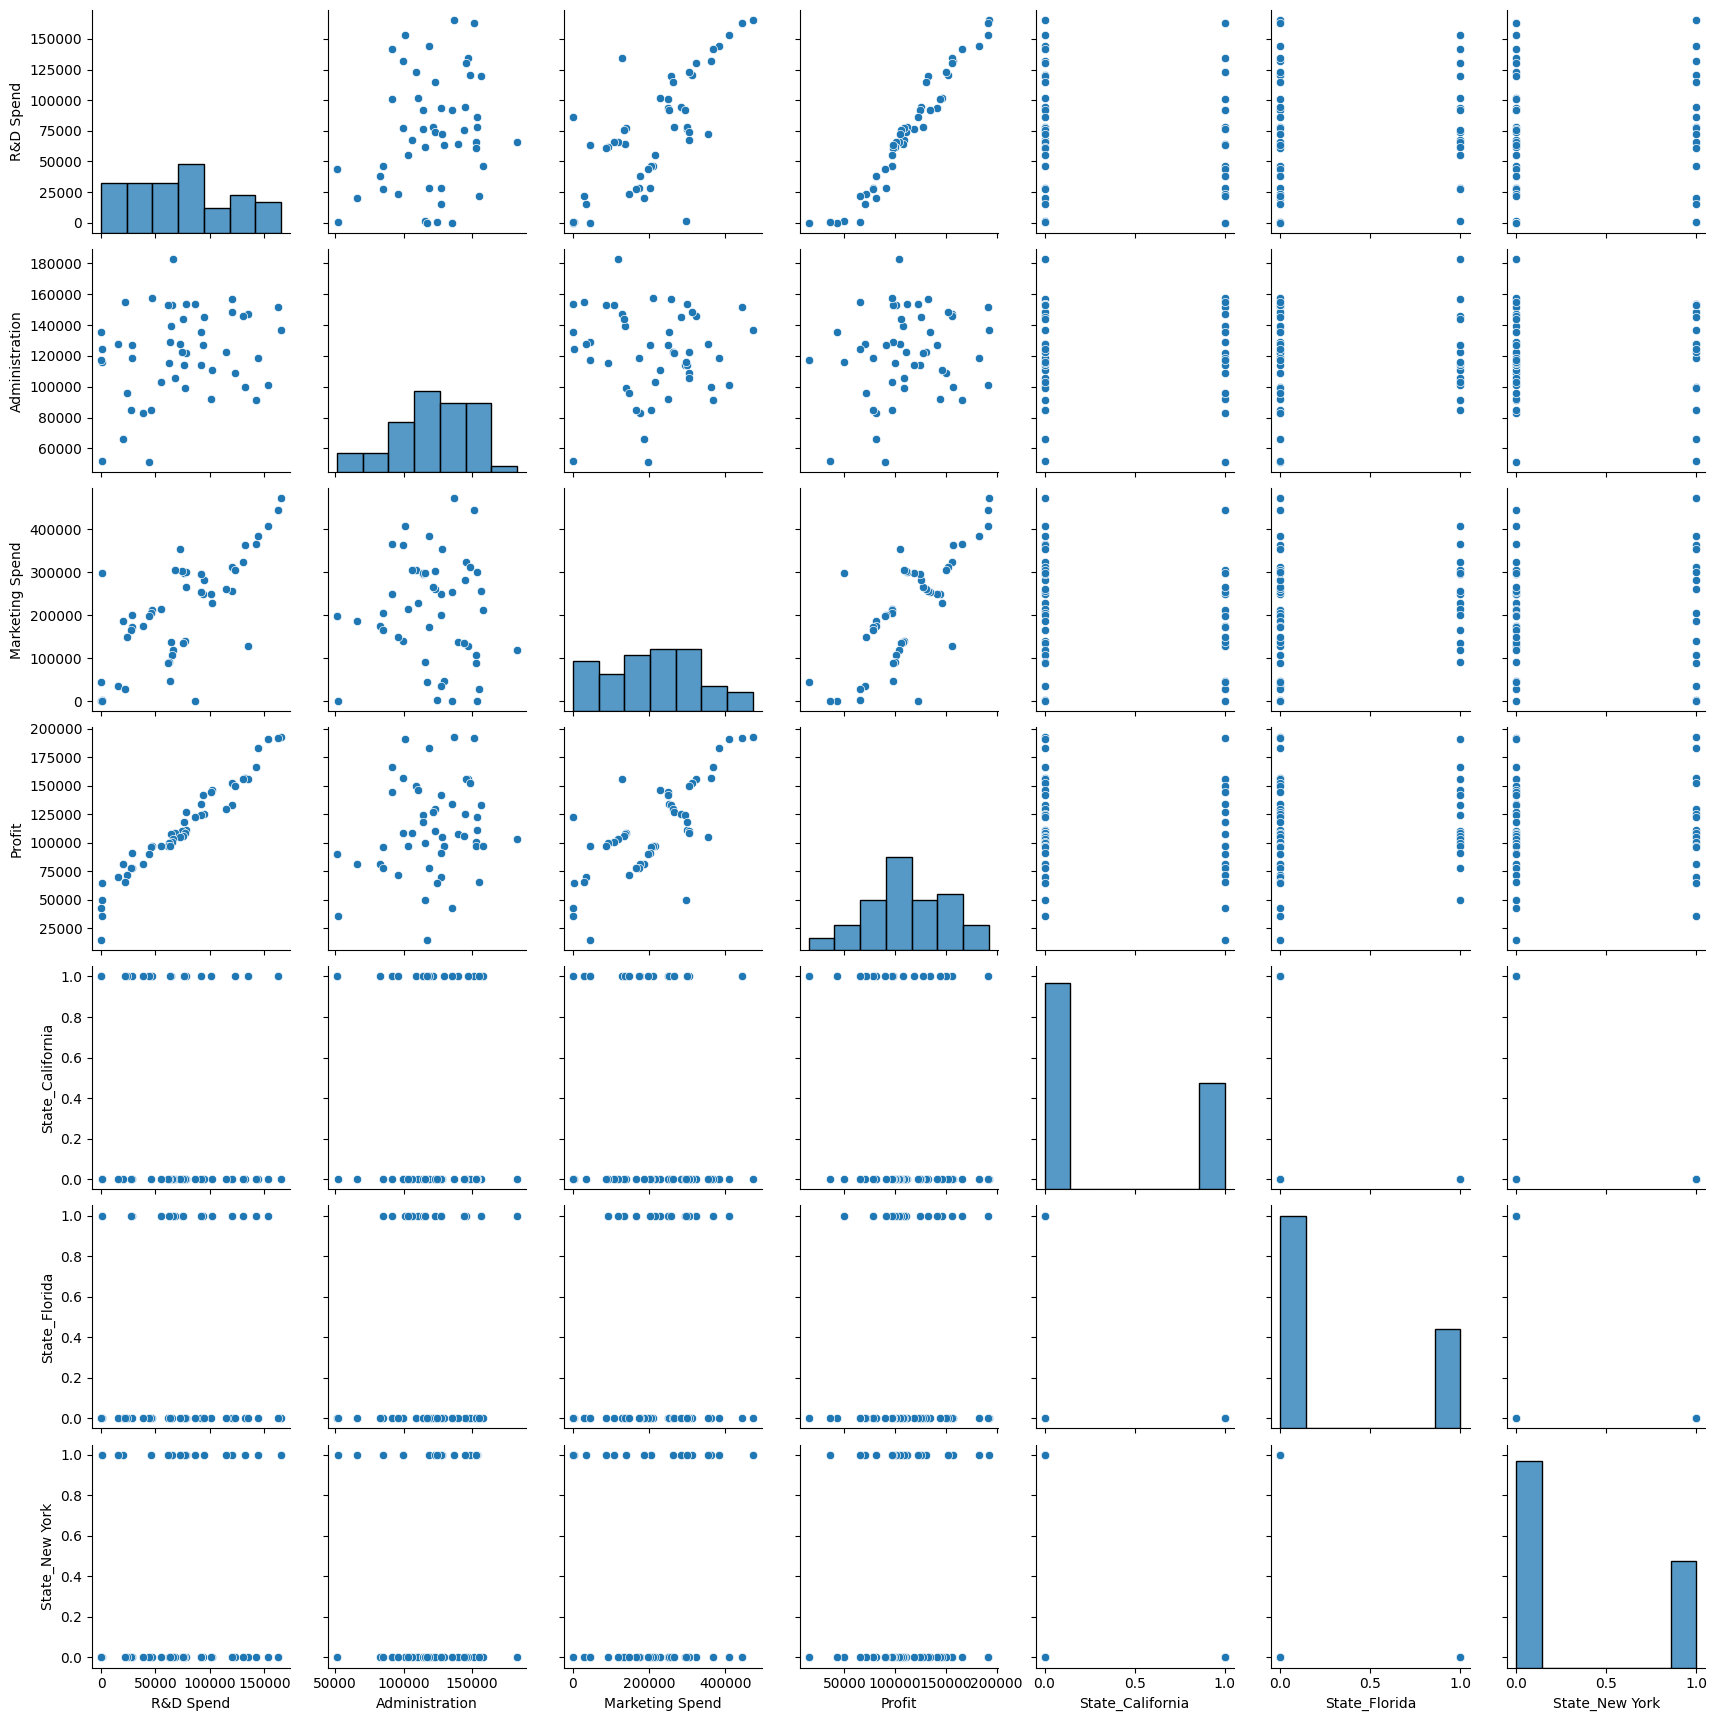

In [18]:
import seaborn as sns
sns.pairplot(df)

In [19]:
df.corr()

,R&D Spend,Administration,Marketing Spend,Profit,State_California,State_Florida,State_New York
R&D Spend,1.000000,0.241955,0.724248,0.972900,-0.143165,0.105711,0.039068
Administration,0.241955,1.000000,-0.032154,0.200717,-0.015478,0.010493,0.005145
Marketing Spend,0.724248,-0.032154,1.000000,0.747766,-0.168875,0.205685,-0.033670
Profit,0.972900,0.200717,0.747766,1.000000,-0.145837,0.116244,0.031368
State_California,-0.143165,-0.015478,-0.168875,-0.145837,1.000000,-0.492366,-0.515152
State_Florida,0.105711,0.010493,0.205685,0.116244,-0.492366,1.000000,-0.492366
State_New York,0.039068,0.005145,-0.033670,0.031368,-0.515152,-0.492366,1.000000


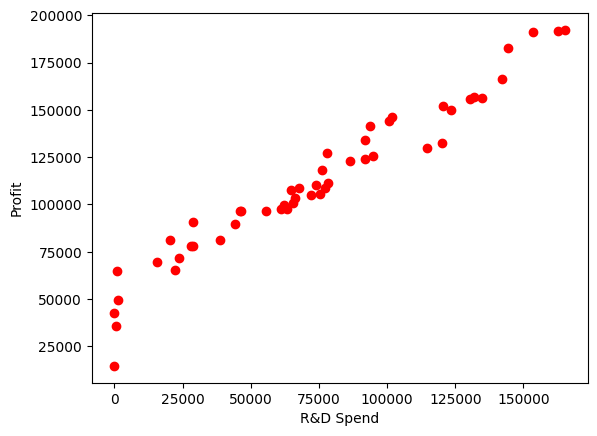

In [20]:
## Visualize it more closely
plt.scatter(x='R&D Spend',y='Profit',color='r',data=df)
plt.xlabel("R&D Spend")
plt.ylabel("Profit")
plt.show()

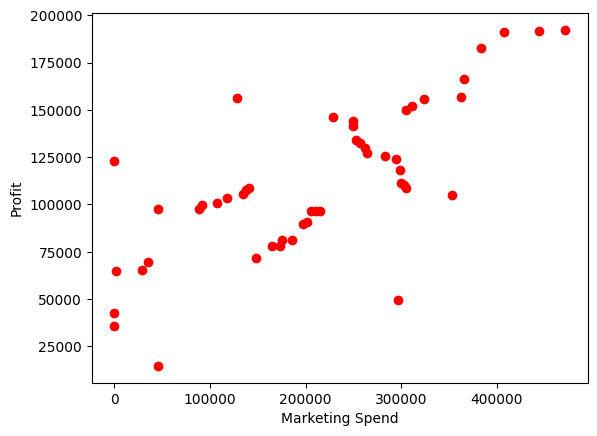

In [21]:
## Visualize it more closely
plt.scatter(x='Marketing Spend',y='Profit',color='r',data=df)
plt.xlabel("Marketing Spend")
plt.ylabel("Profit")
plt.show()

In [24]:
df=pd.get_dummies(drop_first=True,data=df)

In [25]:
df.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_California,State_Florida,State_New York
0,165349.30,136897.90,471784.20,192261.93,0.0,0.0,1.0
1,162597.80,151377.69,443898.63,191792.16,1.0,0.0,0.0
2,153441.61,101145.65,407934.64,191050.49,0.0,1.0,0.0
3,144372.51,118671.95,383199.72,182902.09,0.0,0.0,1.0
4,142107.44,91391.87,366168.52,166188.04,0.0,1.0,0.0


In [40]:
## Getting independent and dependent feature
X=df[['Marketing Spend','R&D Spend']]
y=df['Profit']

In [41]:
## Getting train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

<Axes: xlabel='R&D Spend', ylabel='Profit'>

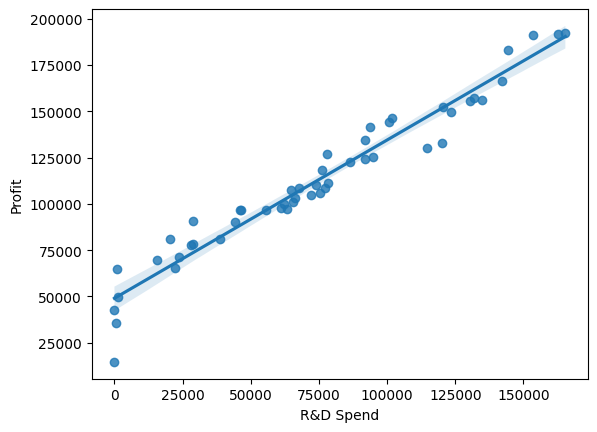

In [42]:
import seaborn as sns
sns.regplot(x=df['R&D Spend'],y=df['Profit'])

<Axes: xlabel='Marketing Spend', ylabel='Profit'>

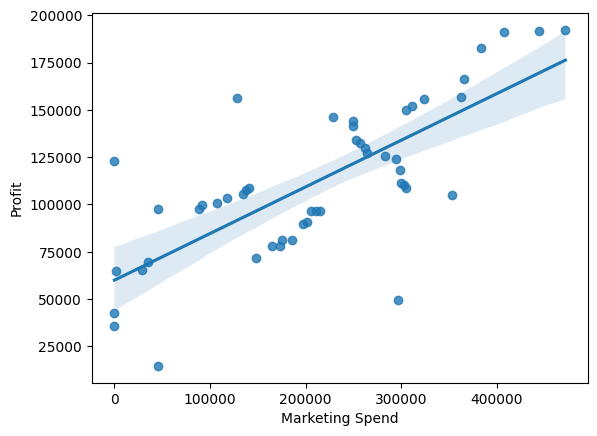

In [43]:
sns.regplot(x=df['Marketing Spend'],y=df['Profit'])

In [44]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [45]:
X_train

array([[-0.85542942,  1.30948713],
       [-0.53664892, -0.96661844],
       [ 0.61382091, -1.53344439],
       [-1.96316611, -1.56149962],
       [ 0.30731897,  0.88098185],
       [ 0.68205579,  1.06890261],
       [ 0.32960808,  0.1023108 ],
       [-0.74390717,  0.0816425 ],
       [-0.13483753, -0.57135605],
       [-1.19801576, -0.25762459],
       [ 2.12879731,  1.96495539],
       [-1.71740828, -1.0885079 ],
       [ 1.10013177, -0.02363789],
       [-0.10155655, -0.37796249],
       [ 1.18406885,  1.25108099],
       [-1.03391408, -0.16231067],
       [ 0.20296362,  0.58556331],
       [-0.2187165 , -0.95017849],
       [ 1.88693513,  1.90627327],
       [ 0.63656972,  0.11033755],
       [ 1.57500573,  1.71099629],
       [-1.6549647 , -1.23080398],
       [-0.18063324, -0.58014397],
       [ 0.68020932, -0.12121186],
       [-0.46444337, -0.94824687],
       [ 0.0244342 ,  0.61203307],
       [ 0.66763751,  0.01660591],
       [ 0.59478379,  0.39526391],
       [-1.57136293,

In [46]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [47]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [48]:
print(regression.coef_)
print(regression.intercept_)

[ 4483.09293462 36450.27863188]
111235.31314285715


In [49]:
y_pred=regression.predict(X_test)

In [50]:
## Performance matrix
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

66537675.846554406
6449.238325233514
8157.062942417106


In [51]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)
## Display adjusted r2
print(1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

0.9527095741745952
0.9448278365370277
